In [ ]:
import sys
from pathlib import Path

# Project root is one level up from notebooks/
_proj_root = Path.cwd().parent
if str(_proj_root / 'src') not in sys.path:
    sys.path.insert(0, str(_proj_root / 'src'))

DATA_DIR = str(_proj_root / 'data')
print(f'Project root: {_proj_root}')
print(f'src in sys.path: {str(_proj_root / "src") in sys.path}')


In [1]:
import math
import numpy as np
%matplotlib inline
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import matplotlib.colors as mcolors
from tabulate import tabulate

from helpers import (
    divide_graph_into_parts,
    calculate_cell_weights,
    plot_cell_weights,
    print_weight_summary,
    suggest_parameters,
    print_parameter_suggestions,
)
from qubo_builder import (
    build_qubo,
    evaluate_solution,
    calibrate_alphas,
    print_qubo_diagnostics,
    brute_force_ranking,
)

In [2]:
# ─────────────────────────────────────────────────────────────────────────────
# Dataset
# ─────────────────────────────────────────────────────────────────────────────

points_of_interest = [
    (1,  15, 0.9),
    (2,  8,  0.6),
    (2,  6,  0.4),
    (7,  12, 0.8),
    (13, 6,  0.3),
]
existing_charging_points = [
    (3,  7),
    (8,  3),
    (11, 8),
]
gas_stations = [
    (5,  10),
    (10, 5),
    (3,  14),
    (9,  15),
]

M            = 3       # new chargers to place
X_MIN, X_MAX = 0, 14
Y_MIN, Y_MAX = 0, 19
SCALE_FACTOR = 5.0
MIN_WEIGHT   = 0.5
N_QUBITS = 16

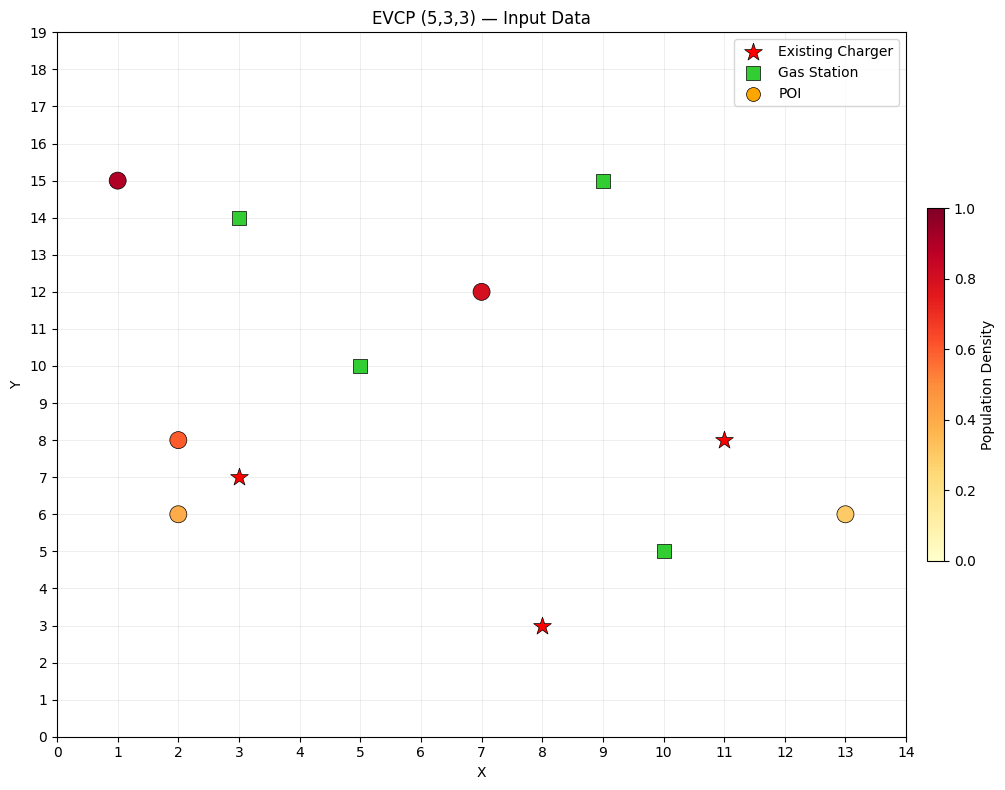

In [3]:
# ─────────────────────────────────────────────────────────────────────────────
# 1. Input data plot
# ─────────────────────────────────────────────────────────────────────────────

fig, ax = plt.subplots(figsize=(11, 8))
sc = ax.scatter(
    [p[0] for p in points_of_interest],
    [p[1] for p in points_of_interest],
    c=[p[2] for p in points_of_interest],
    cmap=cm.YlOrRd, norm=mcolors.Normalize(vmin=0, vmax=1),
    s=150, zorder=5, edgecolors='black', linewidths=0.5
)
plt.colorbar(sc, ax=ax, pad=0.02, shrink=0.5, label='Population Density')
ex_x, ex_y = zip(*existing_charging_points)
ax.scatter(ex_x, ex_y, color='red', s=180, marker='*', zorder=5,
           edgecolors='black', linewidths=0.5, label='Existing Charger')
gs_x, gs_y = zip(*gas_stations)
ax.scatter(gs_x, gs_y, color='limegreen', s=100, marker='s', zorder=5,
           edgecolors='black', linewidths=0.5, label='Gas Station')
ax.scatter([], [], c='orange', s=100, edgecolors='black', linewidths=0.5, label='POI')
ax.set_xticks(range(0, 15))
ax.set_yticks(range(0, 20))
ax.grid(True, linewidth=0.5, alpha=0.3)
ax.set_xlabel('X'); ax.set_ylabel('Y')
ax.set_title('EVCP (5,3,3) — Input Data')
ax.legend(loc='upper right')
plt.tight_layout()
plt.show()

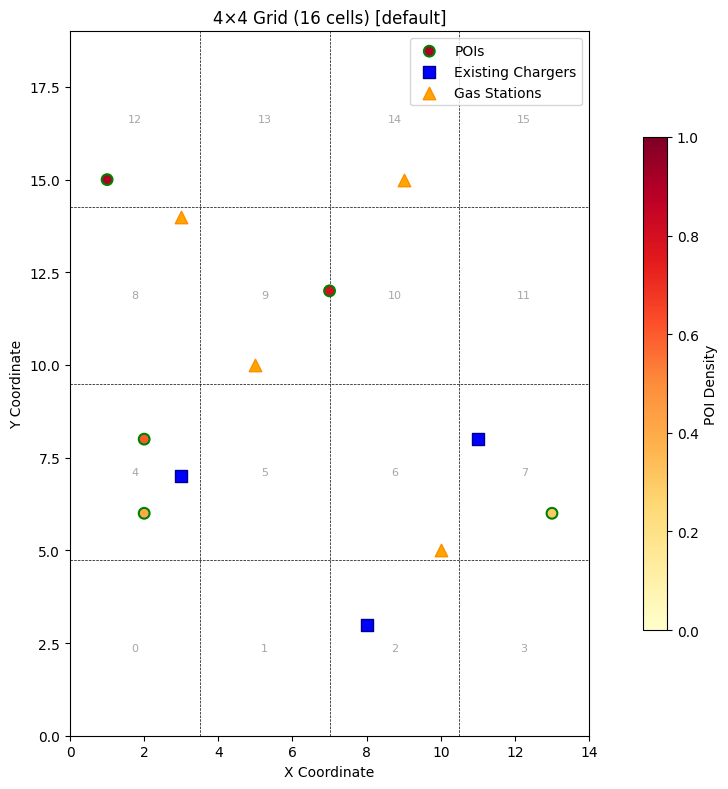

  Grid Info:
    Grid    2 (row=0, col=2): 1 charger(s)
    Grid    4 (row=1, col=0): 2 POI(s) [densities: 0.60, 0.40] | 1 charger(s)
    Grid    6 (row=1, col=2): 1 gas station(s)
    Grid    7 (row=1, col=3): 1 POI(s) [densities: 0.30] | 1 charger(s)
    Grid    8 (row=2, col=0): 1 gas station(s)
    Grid    9 (row=2, col=1): 1 gas station(s)
    Grid   10 (row=2, col=2): 1 POI(s) [densities: 0.80]
    Grid   12 (row=3, col=0): 1 POI(s) [densities: 0.90]
    Grid   14 (row=3, col=2): 1 gas station(s)


In [4]:
# ─────────────────────────────────────────────────────────────────────────────
# 2. Grid discretization
# ─────────────────────────────────────────────────────────────────────────────

grid_details, plot_deets = divide_graph_into_parts(
    x_min=X_MIN, x_max=X_MAX, y_min=Y_MIN, y_max=Y_MAX,
    num_qubits=N_QUBITS,
    points_of_interest=points_of_interest,
    existing_chargers=existing_charging_points,
    gas_stations=gas_stations,
    grid_division="default",
    grid_details_flag=True,
)

CELL WEIGHT SUMMARY
------------------------  ---------
Total cells               16
Cells with POIs           4 (25.0%)
Total aggregated density  3.00
Max weight                5.00
Min non-zero weight       1.50
Total gas stations        4
Total existing chargers   3
------------------------  ---------

TOP 8 CELLS BY WEIGHT (Grid Data Table):
  Grid ID    Row    Col    # POIs    Raw    Norm    Weight    Gas Sta.    Chargers
---------  -----  -----  --------  -----  ------  --------  ----------  ----------
        4      1      0         2    1       1         5             0           1
       12      3      0         1    0.9     0.9       4.5           0           0
       10      2      2         1    0.8     0.8       4             0           0
        7      1      3         1    0.3     0.3       1.5           0           1


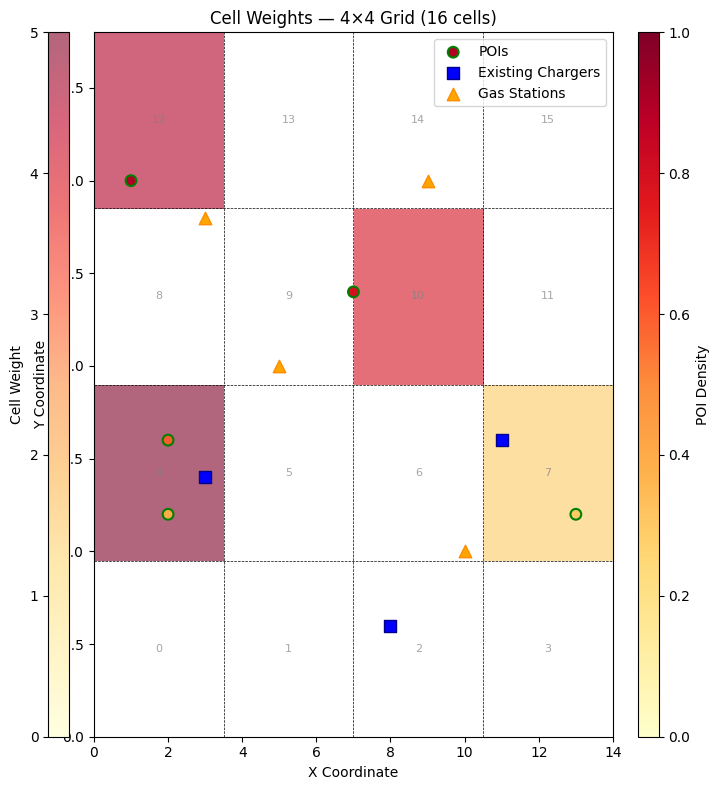

In [5]:
# ─────────────────────────────────────────────────────────────────────────────
# 3. Cell weight calculation
# ─────────────────────────────────────────────────────────────────────────────

cell_weights = calculate_cell_weights(
    grid_details, scale_factor=SCALE_FACTOR, min_weight=MIN_WEIGHT
)
print_weight_summary(cell_weights, grid_details, top_n=8)

plot_cell_weights(
    plot_deets, grid_details, cell_weights,
    points_of_interest=points_of_interest,
    existing_chargers=existing_charging_points,
    gas_stations=gas_stations,
    show_data_points=True, show_weight_values=False,
)

In [6]:
# ─────────────────────────────────────────────────────────────────────────────
# 4. Parameter suggestion (FA-002)
# ─────────────────────────────────────────────────────────────────────────────

params = suggest_parameters(grid_details, cell_weights, plot_deets, m=M)
print_parameter_suggestions(params)

r, a, t    = params['radii'], params['alpha'], params['intra']
lambda_val = params['lambda']

SUGGESTED PARAMETERS

Local Radii:
Radius                                      Value
----------------------------------------  -------
R₁  — H1 POI attraction radius                  2
Rₛ  — service gap radius (matches R₁)           2
R₃  — H3 existing charger penalty radius        1
R₄  — H4 new charger spacing radius             2
R₆  — H6 coverage redundancy radius             1

Objective Weights (α):
Parameter                                     Value
------------------------------------------  -------
α₁  — H1 POI attraction         [dominant]   3
α₂  — H2 gas station bonus                   0.5
α₃  — H3 existing charger penalty            1.02
α₄  — H4 new charger spacing                 1.5
α₅  — H5 constraint  (applied to λ)          1
α₆  — H6 coverage redundancy                 0.5455

Intra-term Magnitudes:
Parameter                                  Value
---------------------------------------  -------
β  — gas station bonus magnitude               1
γ  — existing charger 

In [7]:
# ─────────────────────────────────────────────────────────────────────────────
# 5. QUBO construction
# ─────────────────────────────────────────────────────────────────────────────

Q_obj, h5_params, diags = build_qubo(
    grid_details, cell_weights, plot_deets, m=M,
    alpha1=a['a1'], alpha2=a['a2'], alpha3=a['a3'],
    alpha4=a['a4'], alpha5=a['a5'], alpha6=a['a6'],
    beta=t['beta'], gamma=t['gamma'], delta=t['delta'], epsilon=t['epsilon'],
    lam=lambda_val,
    R1=r['R1'], Rs=r['Rs'], R3=r['R3'], R4=r['R4'], R6=r['R6'],
)

diag_count    = sum(1 for (i, j) in Q_obj if i == j)
offdiag_count = sum(1 for (i, j) in Q_obj if i != j)
diags['diag_entries']    = diag_count
diags['offdiag_entries'] = offdiag_count

In [8]:
# ─────────────────────────────────────────────────────────────────────────────
# 5b. Post-build calibration — rescale α4/α6 if they dominate diagonal
# ─────────────────────────────────────────────────────────────────────────────
# Flatten all build_qubo parameters into one dict so calibrate_alphas
# can update α4/α6 and we can pass **params_flat directly into rebuild.
params_flat = {
    'alpha1':  a['a1'],
    'alpha2':  a['a2'],
    'alpha3':  a['a3'],
    'alpha4':  a['a4'],
    'alpha5':  a['a5'],
    'alpha6':  a['a6'],
    'beta':    t['beta'],
    'gamma':   t['gamma'],
    'delta':   t['delta'],
    'epsilon': t['epsilon'],
    'lam':     lambda_val,
    'R1':      r['R1'],
    'Rs':      r['Rs'],
    'R3':      r['R3'],
    'R4':      r['R4'],
    'R6':      r['R6'],
}

params_flat, needs_rebuild = calibrate_alphas(
    Q_obj, params_flat, diags,
    target_ratio=0.5,   # H4/H6 peaks must not exceed 50% of diagonal peak
    verbose=True,
)

if needs_rebuild:
    print("\nRebuilding Q_obj with calibrated α4/α6...")
    Q_obj, h5_params, diags = build_qubo(
        grid_details, cell_weights, plot_deets, m=M,
        **params_flat,
    )
    print("Rebuild complete.")
else:
    print("\nNo rebuild needed — Q_obj is already well-calibrated.")

print_qubo_diagnostics(diags, params=params_flat)

CALIBRATE_ALPHAS
  Diagonal peak:  3.0000
  Target (×0.5): 1.5000
  H4 actual peak: 0.7500  ✓ OK
  H6 actual peak: 1.5001  ✓ OK
  → No rebuild needed.

No rebuild needed — Q_obj is already well-calibrated.
QUBO CONSTRUCTION DIAGNOSTICS (Q_obj — H1 through H6, H5 separate)

Grid:  N=16 cells,  m=3 new chargers
  POI cells:            4
  Cells w/ chargers:    3
  Individual chargers:  3  (E_all — counts: {2: 1, 4: 1, 7: 1})
  Radii: R1=2, Rs=2, R3=1, R4=2, R6=1

Call parameters:
  alpha1       = 3.0
  alpha2       = 0.5
  alpha3       = 1.02
  alpha4       = 1.5
  alpha5       = 1.0
  alpha6       = 0.5455
  beta         = 1.0
  gamma        = 1.0
  delta        = 1.0
  epsilon      = 1.0
  lam          = 52.5
  R1           = 2
  Rs           = 2
  R3           = 1
  R4           = 2
  R6           = 1

NORMALIZATION SCALES (raw max-abs, divisor applied before α):
  H1 : scale=4.70467  raw range [-4.7047, -0.9154]
  H2 : scale=1.00000  raw range [-1.0000, -0.0000]
  H3 : scale=1.50000 

In [9]:
top_solutions = brute_force_ranking(Q_obj, N=N_QUBITS, m=M, top_k=10)

print(f"TOP 10 over all C({N_QUBITS},{M})={math.comb(N_QUBITS,M)} combinations:\n")
print(f"{'Rank':<6} {'Score':>10}   {'Grid IDs'}")
print("─" * 45)
for rank, (score, sol) in enumerate(top_solutions, 1):
    print(f"  {rank:<4} {score:>10.4f}   {list(sol)}")

TOP 10 over all C(16,3)=560 combinations:

Rank        Score   Grid IDs
─────────────────────────────────────────────
  1       -7.8996   [4, 10, 12]
  2       -7.8152   [4, 12, 14]
  3       -7.1990   [4, 6, 12]
  4       -6.5214   [10, 12, 14]
  5       -6.4215   [4, 12, 13]
  6       -6.3327   [8, 10, 12]
  7       -6.1924   [4, 12, 15]
  8       -6.0976   [4, 10, 14]
  9       -6.0746   [0, 12, 14]
  10      -6.0590   [0, 10, 12]


In [10]:
def plot_Q_matrix(Q_obj, N, title="Q_obj Matrix", clip_percentile=99):
    Q = np.zeros((N, N))
    for (i, j), val in Q_obj.items():
        Q[i, j] = val
        if i != j:
            Q[j, i] = val

    nonzero = Q[Q != 0]
    vmax = np.percentile(np.abs(nonzero), clip_percentile) if len(nonzero) > 0 else 1.0

    plt.figure(figsize=(8, 7))
    plt.imshow(Q, cmap='RdBu_r', vmin=-vmax, vmax=vmax)
    plt.colorbar(label=f'Q value (clipped at {clip_percentile}th pct ± {vmax:.2f})')
    plt.title(title)
    plt.xlabel('Cell j')
    plt.ylabel('Cell i')
    plt.tight_layout()
    plt.show()

    # Plot diagonal only
    diag = np.array([Q_obj.get((i,i), 0.0) for i in range(N)])
    plt.figure(figsize=(10, 2))
    plt.bar(range(N), diag, color=['blue' if v < 0 else 'red' for v in diag])
    plt.axhline(0, color='black', linewidth=0.5)
    plt.title("Diagonal of Q_obj (H1+H2+H3 per cell)")
    plt.xlabel("Cell ID")
    plt.ylabel("Q_ii value")
    plt.tight_layout()
    plt.show()

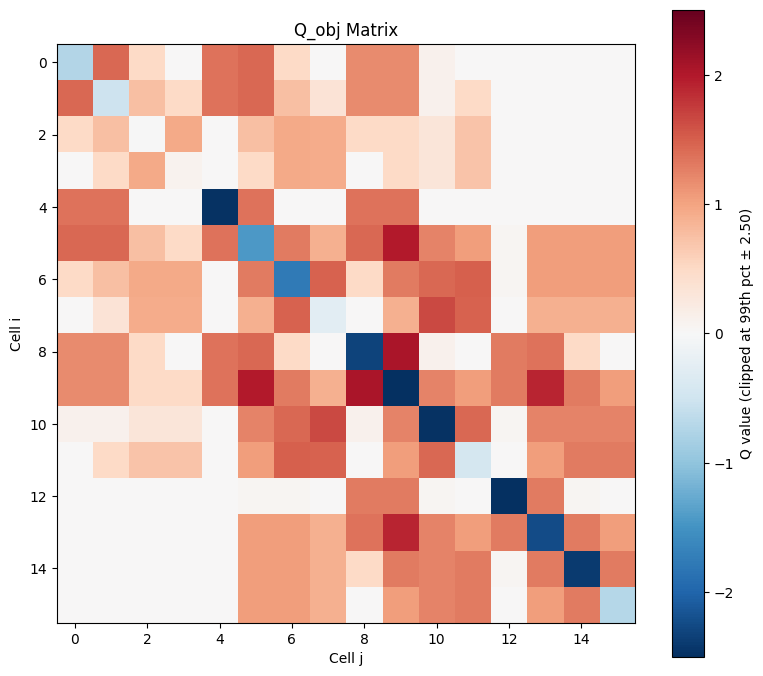

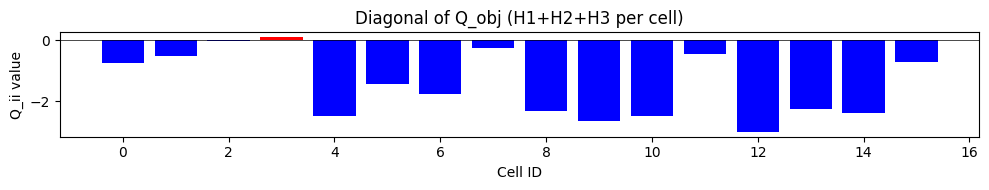

In [11]:
plot_Q_matrix(Q_obj, N_QUBITS)